<a href="https://colab.research.google.com/github/galexter/Proyecto-6---An-lisis-de-la-empresa-ConnectaTel/blob/main/Analisis_Project_ConnectaTel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
import pandas as pd, seaborn as se, matplotlib.pyplot as mat, numpy as np

In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [ ]:
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
users.head()


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users
print(users.isna().sum())
#Proporción para users
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [ ]:
#Cantidad de nulos para usage
print(usage.isna().sum())
#Proporción para usage
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

**Esto es lo que descubrí al revisar los datos faltantes y cómo los voy a manejar:**

- city (11.7% faltantes): No voy a borrar estas filas todavía para no perder información de otros lados. Solo las eliminaré cuando necesite agrupar los datos específicamente por ciudad.
  
- churn_date (88.3% faltantes): ¡Estos nulos son buenos! Significa que el cliente no se ha ido. Usaré esta columna para separar a los clientes en dos grupos: Activos (si la celda está vacía) y Cancelados (si hay una fecha).

- duration y length: Ignorar ya que contiene nulos estructurales por diseño, por lo cual no tiene sentido imputar.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
# explorar columnas numéricas de users
users.select_dtypes(include='number')

,user_id,age
0,10000,38
1,10001,53
2,10002,57
3,10003,69
4,10004,63
...,...,...
3995,13995,60
3996,13996,24
3997,13997,58
3998,13998,57


In [ ]:
# Detectando si existen valores invalidos o sentinels en users
users['age'].describe()

count    4000.000000
mean       33.739750
std       123.232257
min      -999.000000
25%        32.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# explorar columnas numéricas de usage
usage.select_dtypes(include='number')

,id,user_id,duration,length
0,1,10332,0.09,NaN
1,2,11458,NaN,39.0
2,3,11777,NaN,36.0
3,4,10682,1.53,NaN
4,5,12742,4.84,NaN
...,...,...,...,...
39995,39996,13497,5.75,NaN
39996,39997,10941,3.06,NaN
39997,39998,13038,8.74,NaN
39998,39999,10863,NaN,43.0


In [ ]:
# explorar columnas numéricas de usage
usage.select_dtypes(include='number')

,id,user_id,duration,length
0,1,10332,0.09,NaN
1,2,11458,NaN,39.0
2,3,11777,NaN,36.0
3,4,10682,1.53,NaN
4,5,12742,4.84,NaN
...,...,...,...,...
39995,39996,13497,5.75,NaN
39996,39997,10941,3.06,NaN
39997,39998,13038,8.74,NaN
39998,39999,10863,NaN,43.0


In [ ]:
# Revisar que usage no contengan errores
usage['user_id'].describe()

count    40000.000000
mean     12002.405975
std       1157.279564
min      10000.000000
25%      10996.000000
50%      12013.000000
75%      13005.000000
max      13999.000000
Name: user_id, dtype: float64

- Las columnas `id` y `user_id`...Haz doble clic en este bloque y escribe qué ves.
- Las columnas por su lado la columna id sigue un patron secuencial para el uso que le da cada usuario a su servicio por lo cual puede aparecer un usuario mas de una vez con su id en la columna user_id

In [ ]:
# explorar columnas categóricas de users (city)
columnas_user = ['city', 'plan']
users['city'].value_counts(dropna=False)

Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

In [ ]:
# Calculo del porcentaje en (city)
porcentaje = (96 / len(users)) * 100
print(f"Representa el {porcentaje:.2f}% del dataset")

Representa el 2.40% del dataset


In [ ]:
# explorar columnas categóricas de users (plan)
users['plan'].value_counts(dropna=False)

Basico     2595
Premium    1405
Name: plan, dtype: int64

- Durante la revisión de la información de los usuarios, se detectó que en 96 filas de las columnas de ciudad (city) los datos no se registraron correctamente y aparecen con un signo de interrogación (?). Esto equivale al 2.40% del total de nuestros registros. Para asegurar la consistencia del análisis, estos registros serán reemplazados por valores nulos (NaN).

- La columna `plan` contiene datos limpios, solo tiene los valores esperados Basico y Premium

In [ ]:
# explorar columna categórica de usage
usage['type'].value_counts(dropna=False)

text    22092
call    17908
Name: type, dtype: int64

- En la columna `type` encontre que en las columnas text con 22092 , call con 17908 registros, están limpias, no se encontraron valores inesperados por lo tanto no se realizara acción alguna


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
- En las columnas age y city
- ¿Qué acción tomarías?
- Corregir y agregar valores nulos para que no afecte al analisis

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'])
print(users['reg_date'])

0      2022-01-01 00:00:00.000000000
1      2022-01-01 06:34:17.914478619
2      2022-01-01 13:08:35.828957239
3      2022-01-01 19:42:53.743435858
4      2022-01-02 02:17:11.657914478
                    ...             
3995   2024-12-29 21:42:48.342085520
3996   2024-12-30 04:17:06.256564144
3997   2024-12-30 10:51:24.171042768
3998   2024-12-30 17:25:42.085521392
3999   2024-12-31 00:00:00.000000000
Name: reg_date, Length: 4000, dtype: datetime64[ns]


In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'])
print(usage['date'])

0       2024-01-01 00:00:00.000000000
1       2024-01-01 00:06:30.969774244
2       2024-01-01 00:13:01.939548488
3       2024-01-01 00:19:32.909322733
4       2024-01-01 00:26:03.879096977
                     ...             
39995   2024-06-29 23:33:56.120903022
39996   2024-06-29 23:40:27.090677266
39997   2024-06-29 23:46:58.060451510
39998   2024-06-29 23:53:29.030225754
39999   2024-06-30 00:00:00.000000000
Name: date, Length: 40000, dtype: datetime64[ns]


In [ ]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts()

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En `reg_date`, se encontró que existen 40 registros a un año no correspondiente ya que solo existen registros hasta el año 2024, estos registros se remplazaran con valores nulos.

In [ ]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts()

2024.0    39950
Name: date, dtype: int64

En `date`, se se encontró que existen 39950 registros para el 2024
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- Aparecen años sin transcurrir
- ¿Qué harías con ellas?
- Las fechas fuera de rango se marcarán como nulas

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# Reemplazar -999 por la mediana de age

users['age'] = users['age'].replace(-999,np.nan)
age_mediana = users['age'].median()
users['age'] = users['age'].fillna(age_mediana)
# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', np.nan)

# Verificar cambios
users['city'].describe()

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [ ]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'] .dt.year == 2026, 'reg_date'] = pd.NaT
#users['reg_date'] = users['reg_date'].replace('2026', np.nan)

# Verificar cambios
users['reg_date'].describe()

count                              3960
unique                             3960
top       2024-06-27 06:08:22.325581392
freq                                  1
first               2022-01-01 00:00:00
last                2024-12-31 00:00:00
Name: reg_date, dtype: object

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
usage.groupby('type')[['duration']].apply(lambda x: x.isna().sum())

,duration
type,
call,0
text,22076


In [ ]:
# Verificación MAR en usage (Missing At Random) para length
usage.groupby('type')[['length']].apply(lambda x: x.isna().sum())

,length
type,
call,17896
text,0


* Al depender del tipo de registro y al no ser aleatorios si no estructurales, debido a la poca cantidad de datos cruzados la acción es dejarlos como están, no impactan negativamente el analisis

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:

# Columnas auxiliares
usage["text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg(
    cant_mensajes = ('text', 'sum'),
    cant_llamadas = ('call', 'sum'),
    cant_minutos_llamada = ('duration', 'sum')
)
# observar resultado
usage_agg.head(5)

,cant_mensajes,cant_llamadas,cant_minutos_llamada
user_id,,,
10000,7,3,23.70
10001,5,10,33.18
10002,5,2,10.74
10003,11,3,8.99
10004,4,3,8.01


In [ ]:
use_agg = usage_agg.reset_index()

In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(users, use_agg, on='user_id')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas
user_profile[['age','cant_mensajes','cant_llamadas','cant_minutos_llamada']].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000,3999.000000
mean,48.138285,5.524381,4.478120,23.317054
std,17.691541,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [ ]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True)*100

Basico     64.866217
Premium    35.133783
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

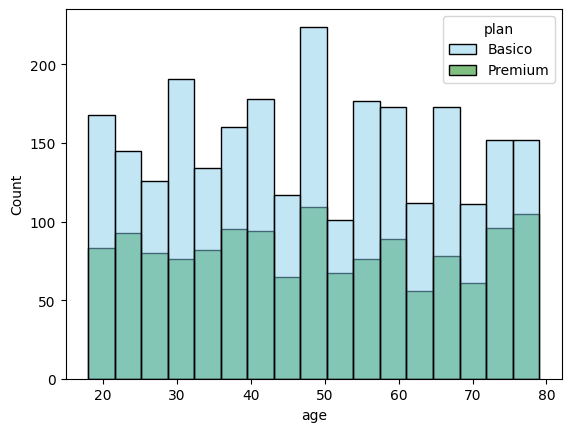

In [ ]:
# Histograma para visualizar la edad (age)
se.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue','green'])
mat.show()

💡Insights:
- La gráfica nos muestra por su distribución visual marcada en el centro de la campana que dentro del plan premium y el básico, hay mayor proporción de usuarios con edades de entre 40 y 50 años de edad, recalcando que la mayoría de usuarios utilizan el plan básico, por lo tanto la distribución de los usuarios es simétrica ya que en la grafica nos muestra que no existe sesgo para la izquierda o derecha.


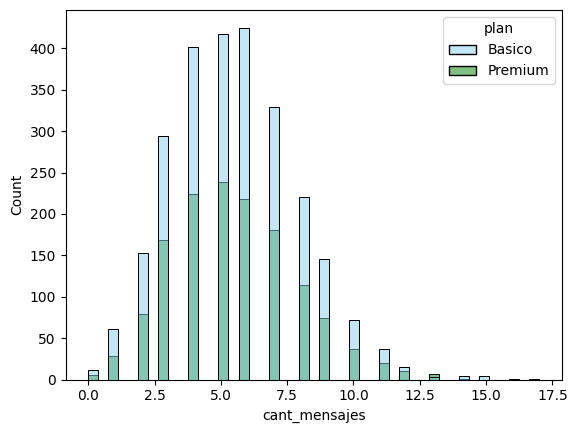

In [ ]:
# Histograma para visualizar la cant_mensajes
se.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue','green'])
mat.show()

💡Insights:
-La gráfica tiene una distribución levemente sesgada hacia la derecha, ya que la mayoría de los usuarios estan concentrados hacia la izquierda.

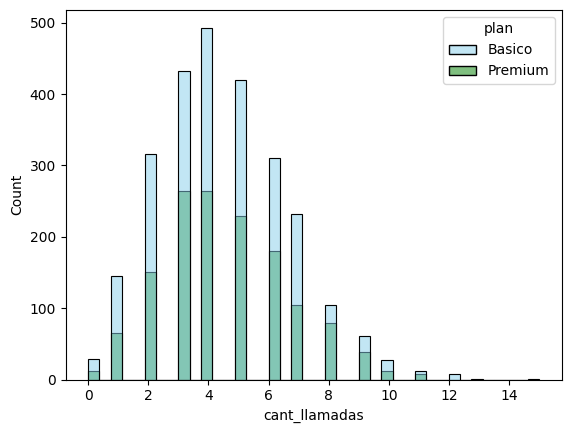

In [ ]:
# Histograma para visualizar la cant_llamadas
se.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue','green'])
mat.show()

💡Insights:
- La gráfica tiene una distribución levemente sesgada hacia la derecha, ya que la mayoría de los usuarios estan concentrados hacia la izquierda.

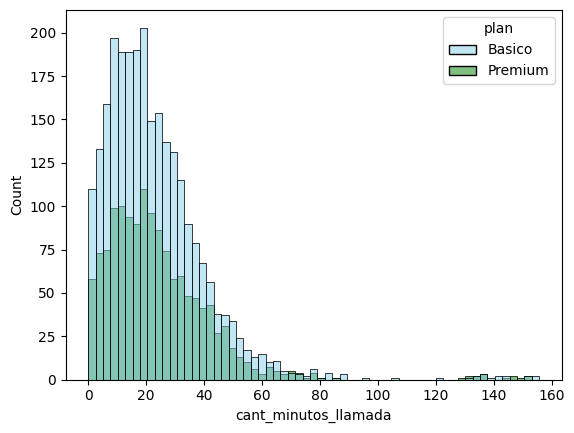

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
se.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue','green'])
mat.show()

💡Insights:
- Esta gráfica tiene una distribución sesgada hacia la derecha.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

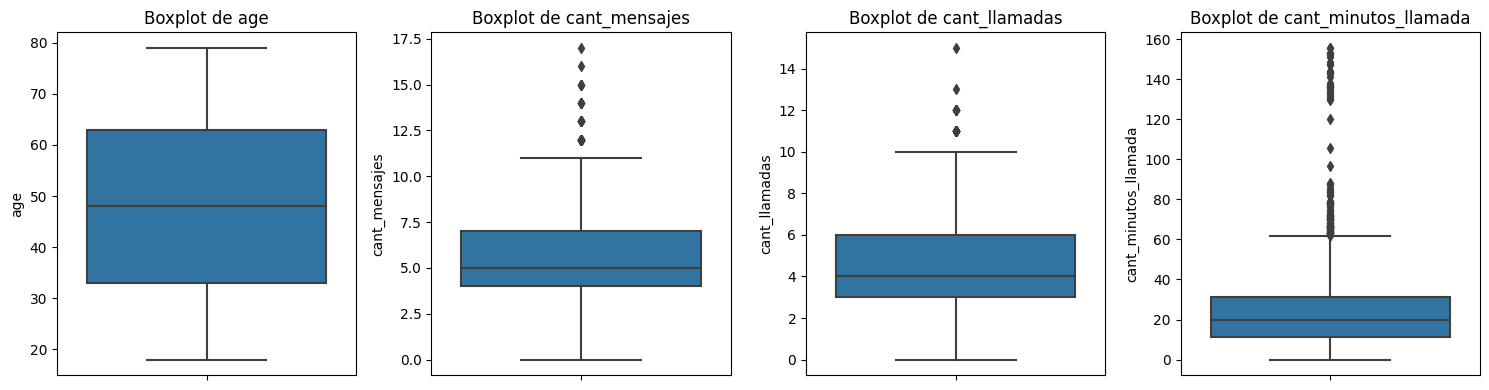

In [ ]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

# Para hacer una cuadrícula de 1 fila x 3 columnas
fig, axes = mat.subplots(1, 4, figsize=(15, 4))
for i, col in enumerate(columnas_numericas):
    # Usamos axes[i] para indicarle a Seaborn exactamente en qué posición pintar
    se.boxplot(data=user_profile, y=col, ax=axes[i])
    axes[i].set_title(f'Boxplot de {col}')
mat.tight_layout() # Ajusta los espacios para que no se encimen los textos
mat.show()

💡Insights:
- Age: No presenta outliers
- cant_mensajes: Presenta outliers (valores atípicos)
- cant_llamadas: Presenta outliers (valores atípicos)
- cant_minutos_llamada: Presenta outliers leves y extremos

In [ ]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes','cant_llamadas','cant_minutos_llamada']
for col in columnas_limites:
    Q1=user_profile[col].quantile(0.25)
    Q3=user_profile[col].quantile(0.75)
    IQR=Q3-Q1
    limite_superior=Q3+1.5*IQR
    print(f'{col}: limite_superior = {limite_superior:.2f}')

cant_mensajes: limite_superior = 11.50
cant_llamadas: limite_superior = 10.50
cant_minutos_llamada: limite_superior = 61.86


In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights:
- cant_mensajes: mantener por que son valores fisicamente posibles.
- cant_llamadas: mantener por que representan comportamiento real de usuarios extremos pero legítimo (como usuarios de negocio).
- cant_minutos_llamada: mantener ya que no impactan significativamente el analisis general.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso

grupo_uso = [
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),   # Bajo uso
    (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10)  # Uso medio
]
opciones = ['Bajo uso', 'Uso medio']
user_profile['grupo_uso'] = np.select(grupo_uso, opciones, default='Alto uso')


In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70,Uso medio
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad
grupo_edad = [
    (user_profile['age'] < 30),   # Edad joven
    (user_profile['age'] < 60)  # Edad adulto
]
opciones = ['Joven', 'Adulto']
user_profile['grupo_edad'] = np.select(grupo_edad, opciones, default='Adulto Mayor')


In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

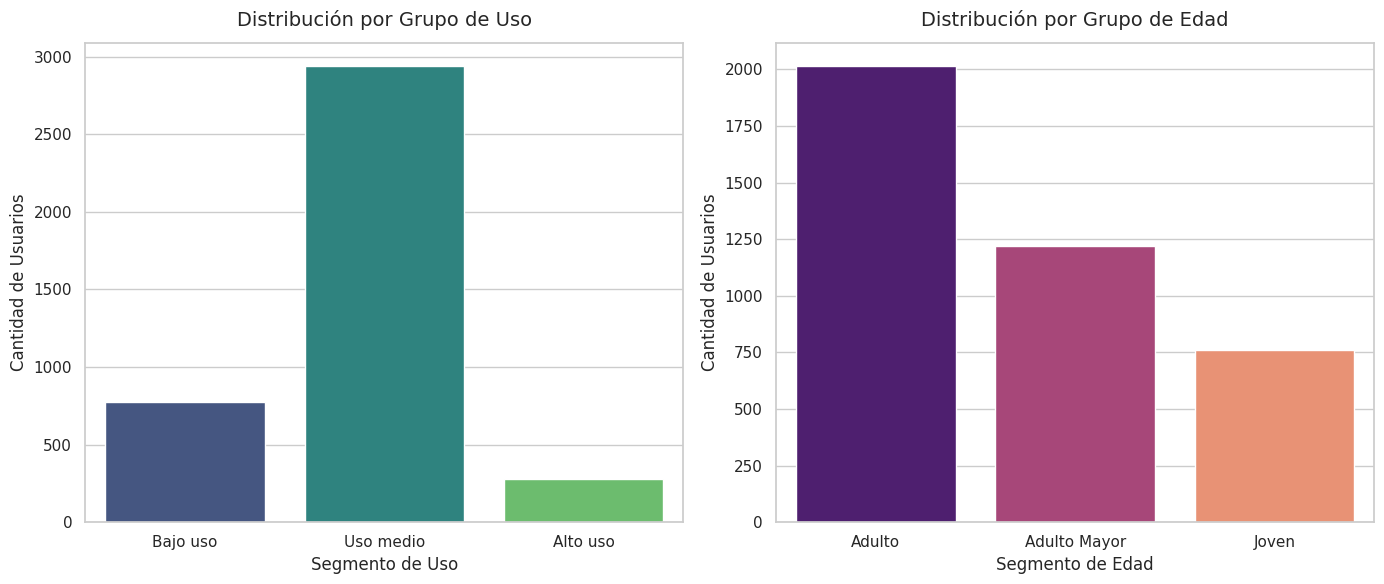

In [ ]:

# Visualización de los segmentos por uso
#configurar para dibujar un grafico a lado del otro
se.set_theme(style="whitegrid")
fig, axes = mat.subplots(1, 2, figsize=(14, 6))
# Define el orden de las categorías
orden_uso = ['Bajo uso', 'Uso medio', 'Alto uso']
orden_edad = sorted(user_profile['grupo_edad'].unique())
#Gráfico de la izquierda: grupo_uso
se.countplot(
    data=user_profile,
    x='grupo_uso',
    order=orden_uso,
    palette='viridis',
    ax=axes[0])
axes[0].set_title('Distribución por Grupo de Uso', fontsize=14, pad=12)
axes[0].set_xlabel('Segmento de Uso', fontsize=12)
axes[0].set_ylabel('Cantidad de Usuarios', fontsize=12)
#Gráfico de la derecha: grupo_edad
se.countplot(
    data=user_profile,
    x='grupo_edad',
    order=orden_edad,
    palette='magma',
    ax=axes[1])
axes[1].set_title('Distribución por Grupo de Edad', fontsize=14, pad=12)
axes[1].set_xlabel('Segmento de Edad', fontsize=12)
axes[1].set_ylabel('Cantidad de Usuarios', fontsize=12)
#Ajustar el espacio entre los gráficos y mostrar
mat.tight_layout()
mat.show()


In [ ]:
#Se calculó el promedio de los 3 segmentos en grupo_edad pra determinar la cantidad de llamadas y mensajes por edad
user_profile.groupby('grupo_edad')[['cant_llamadas', 'cant_mensajes']].mean()

,cant_llamadas,cant_mensajes
grupo_edad,,
Adulto,4.482895,5.548339
Adulto Mayor,4.502455,5.486088
Joven,4.426316,5.522368


In [ ]:
#Se calculó el promedio de los 3 segmentos en grupo_uso para determinar el uso de ambas categorias por cada segmento
user_profile.groupby('grupo_uso')[['cant_llamadas', 'cant_mensajes']].mean()

,cant_llamadas,cant_mensajes
grupo_uso,,
Alto uso,5.946043,9.561151
Bajo uso,2.808483,3.132391
Uso medio,4.780836,5.775399


In [ ]:
user_profile.groupby(['grupo_uso', 'plan']).size()

grupo_uso  plan   
Alto uso   Basico      185
           Premium      93
Bajo uso   Basico      512
           Premium     266
Uso medio  Basico     1897
           Premium    1046
dtype: int64


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
Los principales problemas que se identificaron en algunas columnas fueron datos inconsistentes como sentinels, fechas inexistentes, ciudades sin nombres que representan el 2.40% del dtaset, fechas incorrectas.

- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?
Se identificaron 3 segmentos. Existen tres segmentos de clientes, Jovenes, Adultos y Adultos mayores, estos tienen un comportamiento muy similar ya que sus promedios de uso son muy similares.

- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?
El segmento de alto uso parece ser el mas valioso para ConnectaTel ya que solamente tiene el 33% de usuarios con plan Premium y el 66% con plan básico, lo cual significa que 2 de cada 3 usuarios de alto uso estan en un plan que probablemente no cubre con sus necesidades.
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
Existe un usuario con un probable alto uso del servicio, hipoteticamente este usuario este utilizando el servicio con un alto indice de consumo, lo cual lo convierte en un buen candidato para realizar promociones a su plan para mantenerlo así.

- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

Quizas una promoción de descuento por cambio de plan durante algunos meses para recompenzar que ya tienen un contrato con la empresa y para lograr engancharlos al plan Premium.

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
city 469 nulos 11.7%
churn_date 88.3% nulo = representa usuarios activos
duration 55.1% nulo = es la duracion de llamadas (no tienen longitud de mensaje)
length 44.7% nulo = son los mensajes de texto (no tienen duracion de llamada)
age -999 = sentinels
city con 96 "?" = valores invalidos representan el 2.40%
reg_date 40 registros con fecha no correspondiente al 2026

🔍 **Segmentos por Edad**
- Joven         llamadas = 4.4   mensajes = 5.5
- Adulto        llamadas = 4.5   mensajes = 5.4
- Adulto mayor  llamadas = 4.4   mensajes = 5.7


📊 **Segmentos por Nivel de Uso**
- Alto uso         llamadas = 5.9   mensajes = 9.5
- Bajo uso         llamadas = 2.8   mensajes = 3.1
- Uso medio        llamadas = 4.7   mensajes = 5.7


➡️ Esto sugiere que los usuarios de alto uso tienen un mayor consumo del servicio probablemente debido a sus actividades laborales.


💡 **Recomendaciones**
-Realizar una promoción de descuento por cambio de plan durante algunos meses para recompenzar que ya tienen un contrato con la empresa y para lograr engancharlos al plan Premium.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`